<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  Regresion logistica para predecir la contratacion de depositos a largo plazo en una campaña de marketing bancario.
  <p style="margin: 10px 0 0 0; font-size: 16px; line-height: 1.6; color: #e5e7eb; font-weight: 400;">
    En este proyecto se analiza el dataset, se realiza el EDA, se preparan los datos para Machine Learning y se compara el rendimiento de distintos modelos de regresion logistica.
  </p>
</h2>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Carga de librerias y del conjunto de datos
</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📥 Lectura del dataset
</h2>

In [2]:
df = pd.read_csv("../data/raw/bank-marketing-campaign-data.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.shape)
print(df.columns.tolist())

(41188, 21)
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
🔍 Inspeccion inicial del dataset
</h2>

In [4]:
print("Dimensiones del dataset:", df.shape)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

Dimensiones del dataset: (41188, 21)

Valores nulos por columna:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Filas duplicadas: 12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Revision de la variable objetivo
</h2>

In [6]:
print(df["y"].value_counts())

print("\nPorcentaje de cada clase:")
print(df["y"].value_counts(normalize=True) * 100)

y
no     36548
yes     4640
Name: count, dtype: int64

Porcentaje de cada clase:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  📈 Visualizacion de la distribucion de la variable objetivo
</h2>

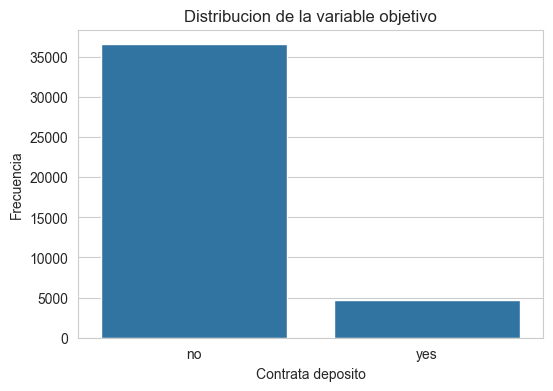

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Distribucion de la variable objetivo")
plt.xlabel("Contrata deposito")
plt.ylabel("Frecuencia")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Tratamiento de filas duplicadas
</h2>

In [8]:
print("Filas antes de eliminar duplicados:", df.shape[0])

df = df.drop_duplicates()

print("Filas despues de eliminar duplicados:", df.shape[0])
print("Duplicados restantes:", df.duplicated().sum())

Filas antes de eliminar duplicados: 41188
Filas despues de eliminar duplicados: 41176
Duplicados restantes: 0


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Clasificacion de variables numericas y categoricas
</h2>

In [9]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Variables numericas:")
print(numeric_features)

print("\nVariables categoricas:")
print(categorical_features)

Variables numericas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Variables categoricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Resumen estadistico de variables numericas
</h2>

In [10]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Distribucion de variables numericas
</h2>

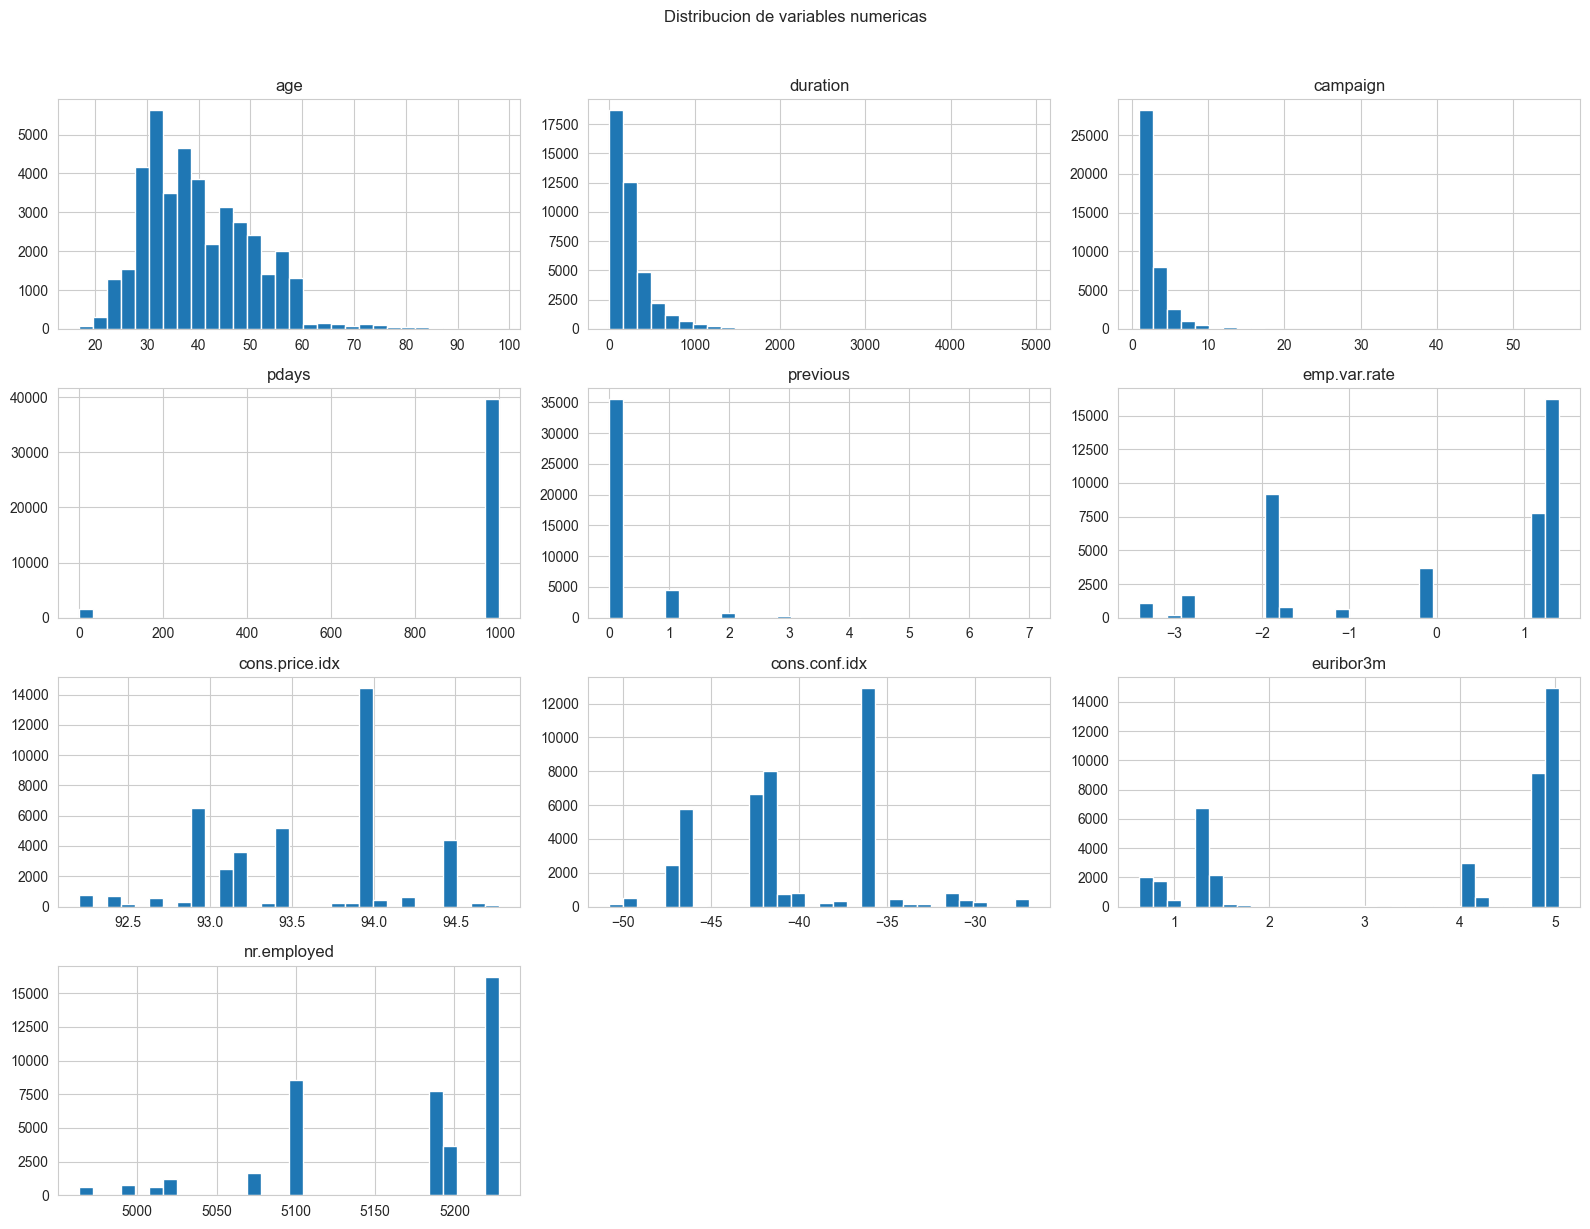

In [11]:
df[numeric_features].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribucion de variables numericas", y=1.02)
plt.tight_layout()
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Deteccion visual de outliers en variables numericas
</h2>

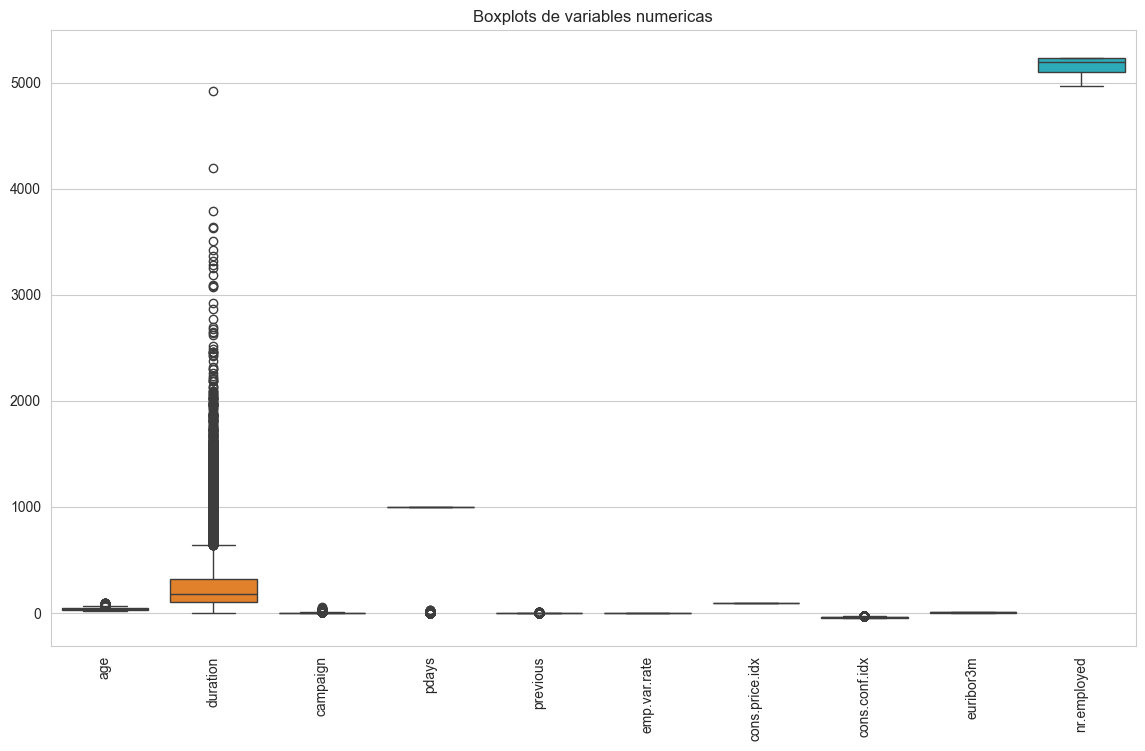

In [12]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=90)
plt.title("Boxplots de variables numericas")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusiones iniciales de las variables numericas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">A partir de los histogramas y boxplots se observa que varias variables numericas presentan distribuciones sesgadas y una cantidad importante de valores extremos, especialmente <span style="color: #ef4444; font-weight: 700;">duration</span>, <span style="color: #ef4444; font-weight: 700;">campaign</span> y <span style="color: #ef4444; font-weight: 700;">previous</span>. La variable <span style="color: #ef4444; font-weight: 700;">age</span> muestra una distribucion mas estable, concentrada principalmente entre los 30 y 50 años.</p><p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Tambien se detecta que <span style="color: #ef4444; font-weight: 700;">pdays</span> esta fuertemente concentrada en el valor 999, lo que sugiere que ese valor representa una condicion especial y no un numero de dias normal. Por otro lado, las variables macroeconomicas presentan valores agrupados en ciertos niveles, algo coherente con su naturaleza de indicadores medidos en momentos concretos.</p><p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">En esta etapa no se eliminaran outliers de forma automatica, ya que primero es necesario validar si representan errores o comportamientos reales del negocio.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Analisis de variables categoricas
</h2>

In [13]:
categorical_features = df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in categorical_features:
    print(f"\nColumna: {col}")
    print(df[col].value_counts())


Columna: job
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Columna: marital
marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64

Columna: education
education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64

Columna: default
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

Columna: housing
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64

Columna: loan
loan
no         33938
yes         6248
unknown 

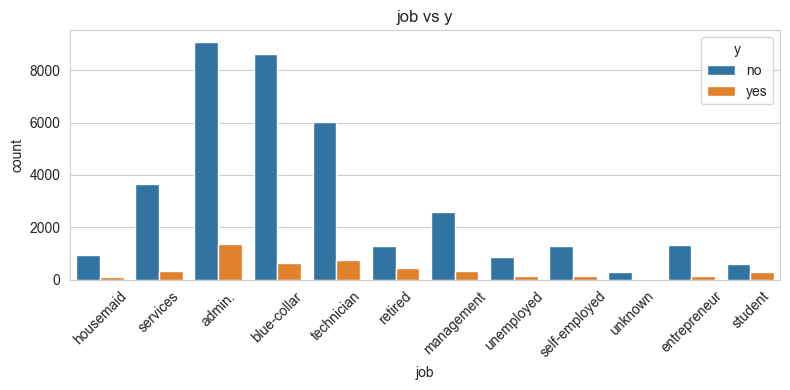

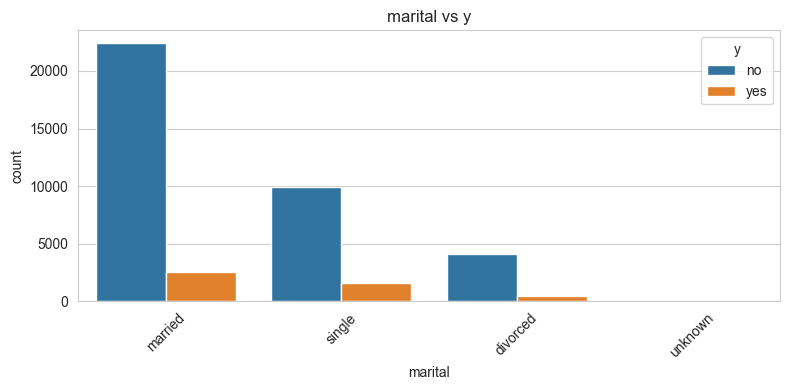

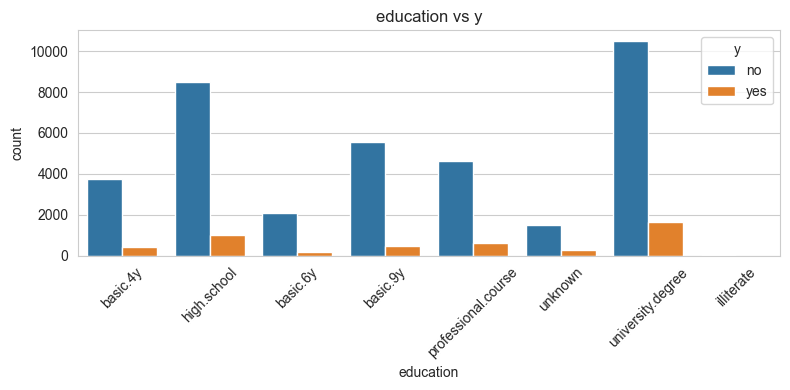

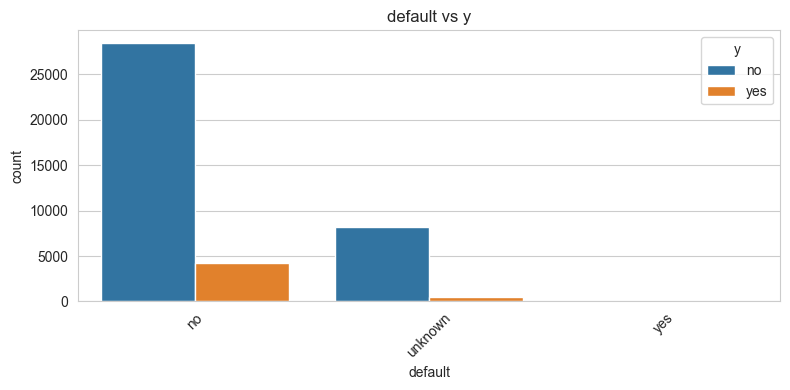

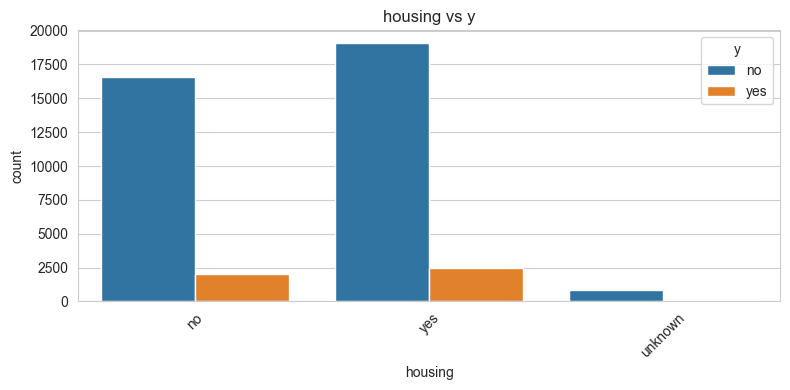

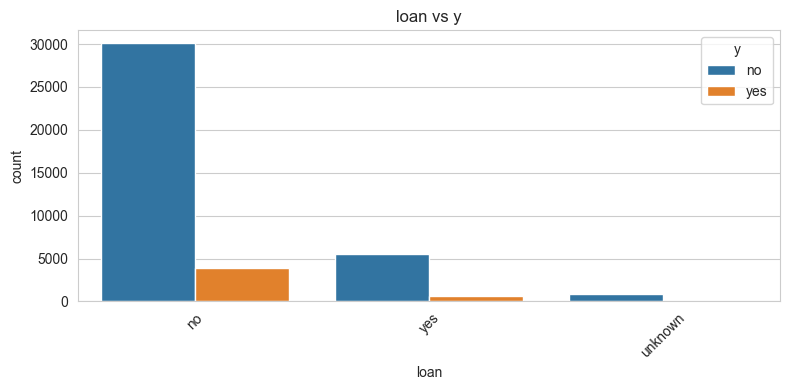

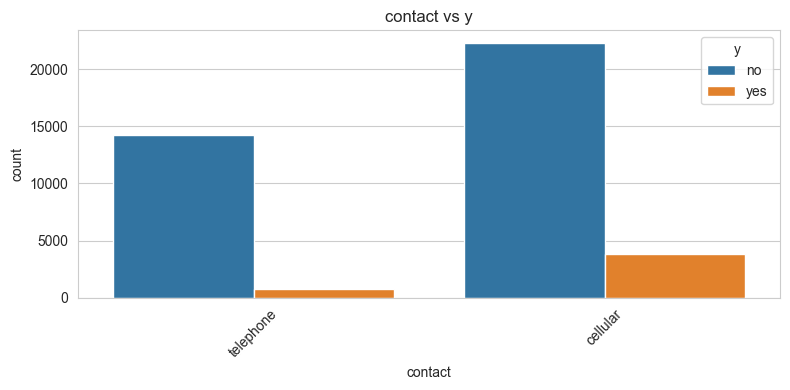

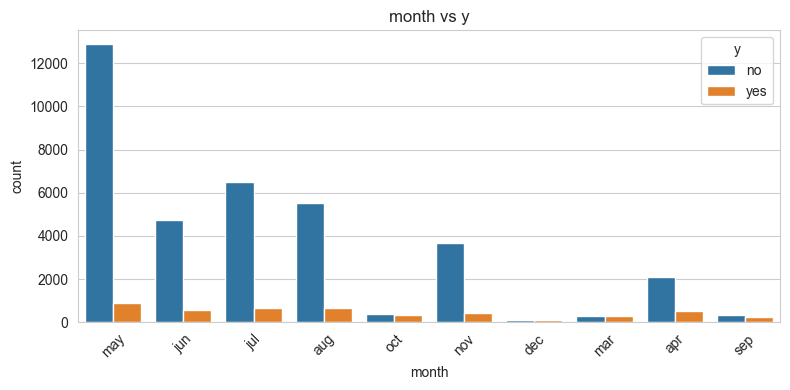

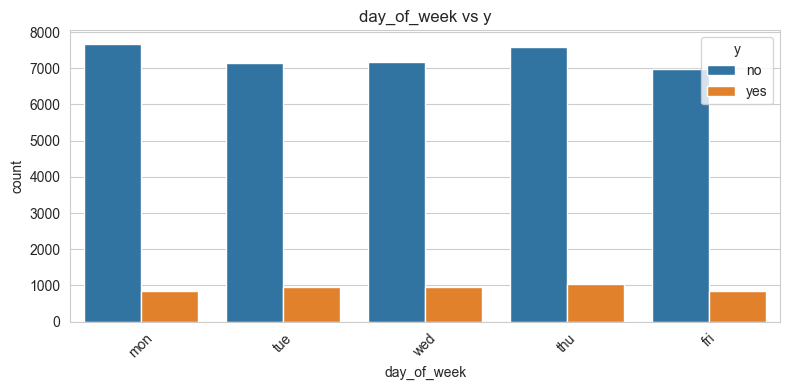

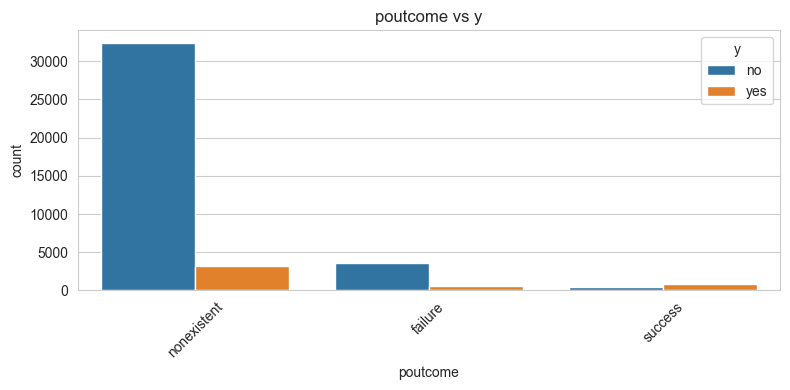

In [14]:
categorical_features_without_target = [col for col in categorical_features if col != "y"]

for col in categorical_features_without_target:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="y")
    plt.title(f"{col} vs y")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusiones iniciales de las variables categoricas
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">A partir del analisis de las variables categoricas se observa que varias columnas presentan categorias dominantes y otras con muy baja frecuencia. Tambien aparecen valores como <span style="color: #ef4444; font-weight: 700;">unknown</span> en varias variables, lo que sugiere ausencia o falta de precision en parte de la informacion recolectada.</p><p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Entre las variables que parecen aportar mas señal para predecir la contratacion del deposito destacan <span style="color: #ef4444; font-weight: 700;">contact</span> y <span style="color: #ef4444; font-weight: 700;">poutcome</span>, ya que muestran diferencias visuales mas marcadas entre las clases <span style="color: #ef4444; font-weight: 700;">no</span> y <span style="color: #ef4444; font-weight: 700;">yes</span>. En especial, la categoria <span style="color: #ef4444; font-weight: 700;">success</span> en <span style="color: #ef4444; font-weight: 700;">poutcome</span> parece asociarse con una mayor probabilidad de respuesta positiva.</p><p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">Por otro lado, variables como <span style="color: #ef4444; font-weight: 700;">default</span> contienen categorias extremadamente poco frecuentes, como <span style="color: #ef4444; font-weight: 700;">yes</span>, que apenas aparece en unos pocos registros. Este tipo de casos debe tenerse en cuenta durante el modelado, aunque por ahora no se eliminara ninguna variable categorica.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
📈 Correlacion entre variables numericas
</h2>

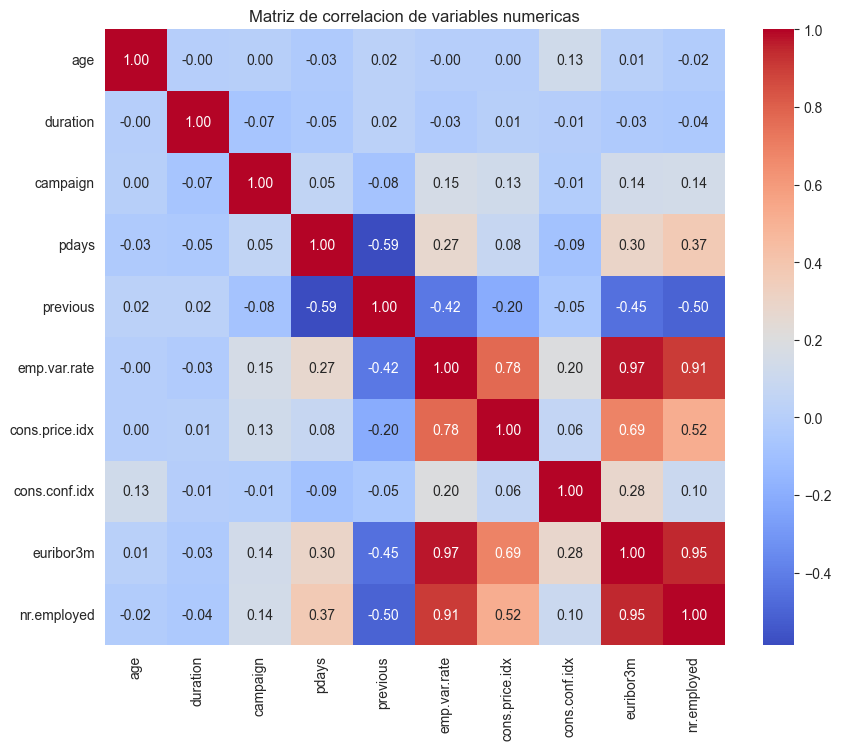

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlacion de variables numericas")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusiones de la matriz de correlacion
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">La matriz de correlacion muestra que varias variables macroeconomicas estan fuertemente relacionadas entre si, especialmente <span style="color: #ef4444; font-weight: 700;">emp.var.rate</span>, <span style="color: #ef4444; font-weight: 700;">euribor3m</span> y <span style="color: #ef4444; font-weight: 700;">nr.employed</span>. Esto sugiere la presencia de multicolinealidad, algo a tener en cuenta al interpretar los coeficientes de la regresion logistica.</p><p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Tambien se observa una correlacion negativa moderada entre <span style="color: #ef4444; font-weight: 700;">pdays</span> y <span style="color: #ef4444; font-weight: 700;">previous</span>, lo cual tiene sentido por la logica del problema, ya que una mayor cantidad de contactos previos suele asociarse con menos casos en los que no hubo contacto anterior.</p><p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">Por otro lado, variables como <span style="color: #ef4444; font-weight: 700;">age</span> y <span style="color: #ef4444; font-weight: 700;">duration</span> muestran correlaciones bajas con el resto. En especial, <span style="color: #ef4444; font-weight: 700;">duration</span> podria aportar informacion adicional, aunque mas adelante habra que evaluar si su uso introduce fuga de informacion desde el punto de vista del negocio.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
⚙️ Preparacion de los datos para el modelado
</h2>

In [16]:
X = df.drop(columns=["y"])
y = df["y"].map({"no": 0, "yes": 1})

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nDistribucion de y:")
print(y.value_counts())

Dimensiones de X: (41176, 20)
Dimensiones de y: (41176,)

Distribucion de y:
y
0    36537
1     4639
Name: count, dtype: int64


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Division en entrenamiento y prueba
</h2>

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (32940, 20)
X_test: (8236, 20)
y_train: (32940,)
y_test: (8236,)


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  Identificacion de variables numericas y categoricas para el pipeline
</h2>

In [18]:
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables numericas:")
print(numeric_features)

print("\nVariables categoricas:")
print(categorical_features)

Variables numericas:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Variables categoricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Preprocesamiento de variables
</h2>

In [19]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Modelo baseline de regresion logistica
</h2>

In [20]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  Evaluacion del modelo baseline
</h2>

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9095434677027683
ROC-AUC: 0.938979837872525

Classification report:

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.65      0.42      0.51       928

    accuracy                           0.91      8236
   macro avg       0.79      0.70      0.73      8236
weighted avg       0.90      0.91      0.90      8236



<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
🔧 Optimizacion del modelo con class_weight balanced
</h2>

In [22]:
optimized_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

optimized_model.fit(X_train, y_train)

y_pred_opt = optimized_model.predict(X_test)
y_proba_opt = optimized_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_opt))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_opt))

Accuracy: 0.8642544924720739
ROC-AUC: 0.9402760968140724

Classification report:

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7308
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8236
   macro avg       0.72      0.88      0.76      8236
weighted avg       0.93      0.86      0.88      8236



<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
📈 Matriz de confusion del modelo optimizado
</h2>

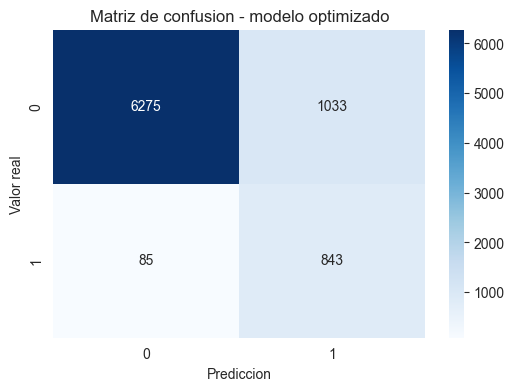

In [23]:
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion - modelo optimizado")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Ajuste del umbral de decision
</h2>

In [24]:
threshold = 0.35
y_pred_threshold = (y_proba_opt >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_opt))

print("\nClassification report con threshold = 0.35:\n")
print(classification_report(y_test, y_pred_threshold))

Accuracy: 0.8284361340456532
ROC-AUC: 0.9402760968140724

Classification report con threshold = 0.35:

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      7308
           1       0.39      0.95      0.56       928

    accuracy                           0.83      8236
   macro avg       0.69      0.88      0.72      8236
weighted avg       0.93      0.83      0.86      8236



<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Comparacion del modelo excluyendo la variable <span style="color: #ef4444; font-weight: 700;">duration</span>
</h2>

In [25]:
X_no_duration = df.drop(columns=["y", "duration"])
y_no_duration = df["y"].map({"no": 0, "yes": 1})

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration, y_no_duration,
    test_size=0.2,
    random_state=42,
    stratify=y_no_duration
)

categorical_features_nd = X_train_nd.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features_nd = X_train_nd.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor_nd = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features_nd),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_nd)
])

model_no_duration = Pipeline(steps=[
    ("preprocessor", preprocessor_nd),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ))
])

model_no_duration.fit(X_train_nd, y_train_nd)

y_pred_nd = model_no_duration.predict(X_test_nd)
y_proba_nd = model_no_duration.predict_proba(X_test_nd)[:, 1]

print("Accuracy:", accuracy_score(y_test_nd, y_pred_nd))
print("ROC-AUC:", roc_auc_score(y_test_nd, y_proba_nd))

print("\nClassification report sin duration:\n")
print(classification_report(y_test_nd, y_pred_nd))

Accuracy: 0.8302574065080136
ROC-AUC: 0.800231397924806

Classification report sin duration:

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Ajuste del umbral de decision en el modelo sin <span style="color: #ef4444; font-weight: 700;">duration</span>
</h2>

In [28]:
threshold = 0.40
y_pred_nd_threshold = (y_proba_nd >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test_nd, y_pred_nd_threshold))
print("ROC-AUC:", roc_auc_score(y_test_nd, y_proba_nd))

print("\nClassification report con threshold = 0.40:\n")
print(classification_report(y_test_nd, y_pred_nd_threshold))

Accuracy: 0.7504856726566295
ROC-AUC: 0.800231397924806

Classification report con threshold = 0.40:

              precision    recall  f1-score   support

           0       0.96      0.75      0.84      7308
           1       0.27      0.73      0.40       928

    accuracy                           0.75      8236
   macro avg       0.61      0.74      0.62      8236
weighted avg       0.88      0.75      0.79      8236



<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
📈 Matriz de confusion del modelo sin <span style="color: #ef4444; font-weight: 700;">duration</span>
</h2>

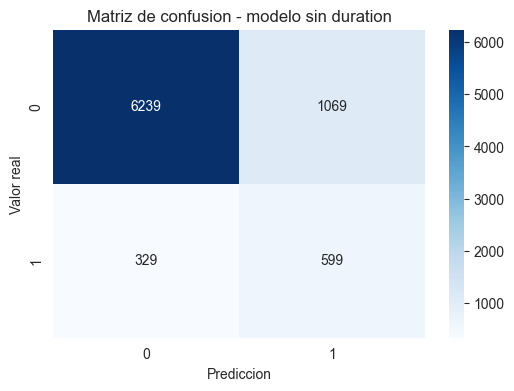

In [29]:
cm_nd = confusion_matrix(y_test_nd, y_pred_nd)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nd, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion - modelo sin duration")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
📈 Matriz de confusion del modelo sin <span style="color: #ef4444; font-weight: 700;">duration</span> con threshold 0.40
</h2>

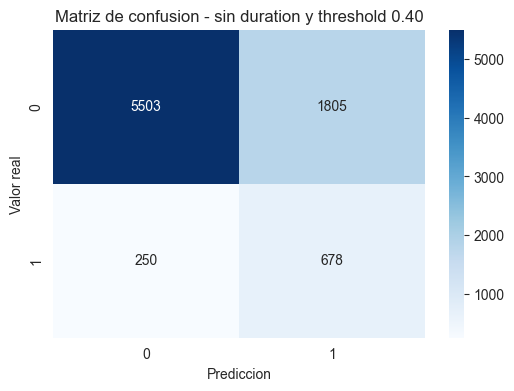

In [30]:
cm_nd_threshold = confusion_matrix(y_test_nd, y_pred_nd_threshold)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_nd_threshold, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusion - sin duration y threshold 0.40")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Interpretacion del modelo sin <span style="color: #ef4444; font-weight: 700;">duration</span>
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Al excluir la variable <span style="color: #ef4444; font-weight: 700;">duration</span>, el rendimiento global del modelo disminuye de forma notable, especialmente en accuracy y ROC-AUC. Sin embargo, el recall de la clase positiva mejora de forma clara, lo que significa que el modelo logra identificar una mayor proporcion de clientes que si contratarian el deposito.</p><p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">Este comportamiento sugiere un intercambio entre precision y sensibilidad. El modelo sin <span style="color: #ef4444; font-weight: 700;">duration</span> resulta menos preciso al marcar clientes como potencialmente interesados, pero a cambio reduce la cantidad de positivos reales que se escapan. Desde una perspectiva de negocio, esta version puede considerarse mas realista, ya que evita depender de una variable que podria introducir fuga de informacion.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Conclusion final del modelado
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">El modelo baseline de regresion logistica obtuvo metricas globales muy altas, especialmente en accuracy y ROC-AUC. Sin embargo, parte de ese rendimiento puede estar influido por la variable <span style="color: #ef4444; font-weight: 700;">duration</span>, la cual puede introducir fuga de informacion si el objetivo es predecir la contratacion antes de realizar o completar la llamada.</p><p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Por este motivo, se entreno una segunda version del modelo excluyendo <span style="color: #ef4444; font-weight: 700;">duration</span> y utilizando <span style="color: #ef4444; font-weight: 700;">class_weight=&amp;quot;balanced&amp;quot;</span>. Aunque esta version redujo el rendimiento global, mejoro de forma importante el recall de la clase positiva, lo que permite identificar una mayor proporcion de clientes potencialmente interesados en contratar el deposito.</p><p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">Tambien se evaluo una variante con umbral de decision de <span style="color: #ef4444; font-weight: 700;">0.40</span>, la cual aumento aun mas el recall, pero a costa de una caida importante en precision y accuracy. En consecuencia, se considera que el modelo mas equilibrado para este problema es la regresion logistica sin <span style="color: #ef4444; font-weight: 700;">duration</span>, con clases balanceadas y umbral por defecto, mientras que la version con umbral ajustado puede verse como una alternativa mas agresiva si el banco prefiere priorizar la deteccion de clientes potenciales sobre la reduccion de llamadas innecesarias.</p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Tabla comparativa de modelos
</h2>

In [31]:
comparison = pd.DataFrame({
    "Modelo": [
        "Baseline con duration",
        "Sin duration + balanced",
        "Sin duration + balanced + threshold 0.40"
    ],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred), 4),
        round(accuracy_score(y_test_nd, y_pred_nd), 4),
        round(accuracy_score(y_test_nd, y_pred_nd_threshold), 4)
    ],
    "ROC-AUC": [
        round(roc_auc_score(y_test, y_proba), 4),
        round(roc_auc_score(y_test_nd, y_proba_nd), 4),
        round(roc_auc_score(y_test_nd, y_proba_nd), 4)
    ],
    "Precision clase 1": [
        round(classification_report(y_test, y_pred, output_dict=True)["1"]["precision"], 4),
        round(classification_report(y_test_nd, y_pred_nd, output_dict=True)["1"]["precision"], 4),
        round(classification_report(y_test_nd, y_pred_nd_threshold, output_dict=True)["1"]["precision"], 4)
    ],
    "Recall clase 1": [
        round(classification_report(y_test, y_pred, output_dict=True)["1"]["recall"], 4),
        round(classification_report(y_test_nd, y_pred_nd, output_dict=True)["1"]["recall"], 4),
        round(classification_report(y_test_nd, y_pred_nd_threshold, output_dict=True)["1"]["recall"], 4)
    ],
    "F1 clase 1": [
        round(classification_report(y_test, y_pred, output_dict=True)["1"]["f1-score"], 4),
        round(classification_report(y_test_nd, y_pred_nd, output_dict=True)["1"]["f1-score"], 4),
        round(classification_report(y_test_nd, y_pred_nd_threshold, output_dict=True)["1"]["f1-score"], 4)
    ]
})

comparison

,Modelo,Accuracy,ROC-AUC,Precision clase 1,Recall clase 1,F1 clase 1
0,Baseline con duration,0.9095,0.9390,0.6522,0.4224,0.5128
1,Sin duration + balanced,0.8303,0.8002,0.3591,0.6455,0.4615
2,Sin duration + balanced + threshold 0.40,0.7505,0.8002,0.2731,0.7306,0.3975


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
  Conclusion de negocio y recomendacion final
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 12px 0; line-height: 1.75; color: #111827; font-size: 16px;">Desde la perspectiva del negocio, el uso de la regresion logistica permite priorizar clientes con mayor probabilidad de contratar un deposito a largo plazo. Aunque el modelo con <span style="color: #ef4444; font-weight: 700;">duration</span> ofrece mejores metricas globales, el modelo sin esta variable resulta mas coherente con un escenario real de decision previa al contacto. Ademas, al ajustar el balance de clases, se mejora la deteccion de clientes potenciales, lo cual puede ayudar al banco a enfocar mejor sus esfuerzos comerciales</p>
</div>